# Ejercicio 3 — Mejora del clasificador de dígitos con más datos

**Objetivo del enunciado:** alcanzar una accuracy mayor o igual al **98 %** usando los datos nuevos (`more_digits.csv`). Preguntas: (a) ¿cuál es el mejor resultado obtenido?, (b) ¿qué técnicas se usaron para mejorar respecto del ejercicio 2?, (c) ¿qué otros factores influyeron en el cambio de rendimiento?

**Reglas de uso de los datos:** `digits.csv` y `more_digits.csv` se usan para ajustar parámetros e hiperparámetros; `digits_test.csv` se reserva para medir generalización y nunca interviene en una decisión.

**Implementación:** el modelo (`DigitMLP`), el entrenamiento (`fit`) y la carga (`load_digits`) son los mismos del ejercicio 2, ahora en el módulo `mlp.py`. `fit` suma la pérdida de validación por época y la opción de quedarse con los pesos de la mejor época en validación. El módulo agrega además las dos técnicas evaluadas en este notebook: aumento de datos (`augment_digits`) y ponderación de la pérdida por clase (`balanced_class_weights`).

In [15]:
from pathlib import Path
import hashlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

os.environ.setdefault('OPENBLAS_NUM_THREADS', '2')
SEED = 42
DATA_DIR = Path.cwd() / 'data' if (Path.cwd() / 'data' / 'digits.csv').exists() else Path.cwd() / 'TP3' / 'data'
assert (DATA_DIR / 'digits.csv').exists(), 'Abrir el notebook desde TP3 o desde la raíz del repositorio.'
sys.path.insert(0, str(DATA_DIR.parent))
from mlp import DigitMLP, fit, load_digits

FIG_DIR = DATA_DIR.parent / 'figures_ej3'
FIG_DIR.mkdir(exist_ok=True)


def show(name):
    """Guarda la figura actual en figures_ej3/ y la muestra."""
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate(model, X, y):
    """Accuracy, F1 macro e informe por clase de un modelo sobre (X, y)."""
    pred = model.predict(X)
    report = classification_report(y, pred, labels=range(10), output_dict=True, zero_division=0)
    return accuracy_score(y, pred), report['macro avg']['f1-score'], report, pred


print('Datos:', DATA_DIR.resolve())

Datos: C:\Users\maria\repos\DIAO2A\TP3\data


## 1. Datos

Antes de entrenar comparamos los tres archivos: cuántas imágenes aporta cada uno por clase, cuántas están repetidas y si alguna imagen de test aparece también en los datos de desarrollo.

,digits.csv,more_digits.csv,digits_test.csv
Dígito,,,
0,1480,1776,245
1,1685,2022,283
2,1489,1787,258
3,1532,1839,252
4,1460,1752,245
5,271,542,223
6,1479,1775,239
7,1566,1879,257
8,0,585,243


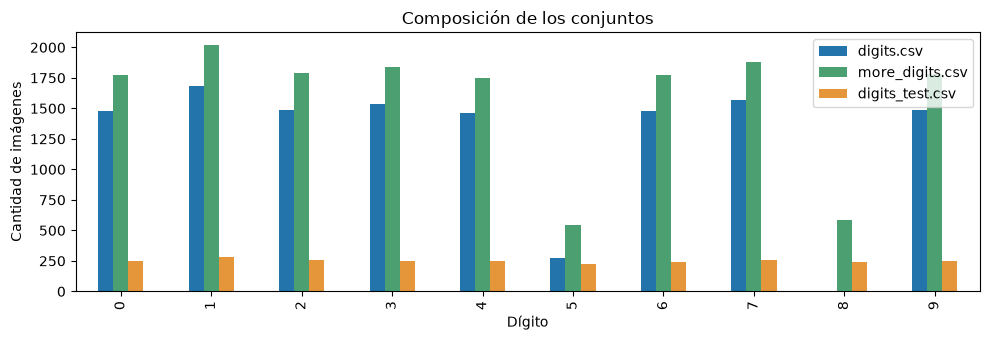

In [16]:
X_old, y_old = load_digits(DATA_DIR / 'digits.csv')
X_more, y_more = load_digits(DATA_DIR / 'more_digits.csv')
X_test, y_test = load_digits(DATA_DIR / 'digits_test.csv')

counts = pd.DataFrame({
    name: pd.Series(labels).value_counts().reindex(range(10), fill_value=0)
    for name, labels in [('digits.csv', y_old), ('more_digits.csv', y_more), ('digits_test.csv', y_test)]
})
counts.index.name = 'Dígito'
display(counts)
ax = counts.plot.bar(figsize=(10, 3.5), color=['#2374AB', '#4C9F70', '#E5953A'])
ax.set(ylabel='Cantidad de imágenes', title='Composición de los conjuntos')
plt.tight_layout()
show('distribucion_clases_ej3')

In [17]:
def keys(X):
    return pd.Series([hashlib.md5(row.tobytes()).hexdigest() for row in X])

k_old, k_more, k_test = keys(X_old), keys(X_more), keys(X_test)
X_all = np.concatenate([X_old, X_more])
y_all = np.concatenate([y_old, y_more])
k_all = pd.concat([k_old, k_more], ignore_index=True)

labels_per_image = pd.Series(y_all).groupby(k_all.to_numpy()).nunique()
duplicates = pd.Series({
    'Repetidas dentro de digits.csv': int(k_old.duplicated().sum()),
    'Repetidas dentro de more_digits.csv': int(k_more.duplicated().sum()),
    'Imágenes de more_digits.csv que ya estaban en digits.csv': int(k_more.isin(set(k_old)).sum()),
    'Imágenes repetidas con etiquetas distintas': int((labels_per_image > 1).sum()),
    'Imágenes de test presentes en desarrollo': int(k_test.isin(set(k_all)).sum()),
}, name='Cantidad')
display(duplicates.to_frame())

keep = ~k_all.duplicated().to_numpy()
X_dev, y_dev = X_all[keep], y_all[keep]
dev_counts = pd.Series(y_dev).value_counts().reindex(range(10), fill_value=0)
print(f'Desarrollo combinado sin repetidas: {len(y_dev):,} imágenes (antes {len(y_all):,}) | Test: {len(y_test):,}')
print('Imágenes por clase:', dev_counts.to_dict())

,Cantidad
Repetidas dentro de digits.csv,0
Repetidas dentro de more_digits.csv,0
Imágenes de more_digits.csv que ya estaban en digits.csv,3689
Imágenes repetidas con etiquetas distintas,0
Imágenes de test presentes en desarrollo,0


Desarrollo combinado sin repetidas: 24,501 imágenes (antes 28,190) | Test: 2,497
Imágenes por clase: {0: 2795, 1: 3212, 2: 2817, 3: 2895, 4: 2788, 5: 785, 6: 2825, 7: 2969, 8: 585, 9: 2830}


## 2. Punto de partida: el modelo del ejercicio 2

Reentrenamos la configuración elegida en el ejercicio 2 — capas ocultas (128, 64), ReLU, momentum, tasa 0,1, minibatches de 256 y 50 épocas — solo con `digits.csv`. Es la referencia contra la que se mide toda mejora.

In [18]:
HIDDEN, LR, OPTIMIZER = (128, 64), 0.1, 'momentum'
EPOCHS, BATCH_SIZE = 50, 256

results = []
def register(name, model, n_train):
    accuracy, f1, report, pred = evaluate(model, X_test, y_test)
    results.append({'Experimento': name, 'Imágenes de entrenamiento': n_train, 'Accuracy test': accuracy,
                    'F1 macro test': f1, 'Recall del 5': report['5']['recall'], 'Recall del 8': report['8']['recall']})
    return accuracy, report, pred

baseline = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
fit(baseline, X_old, y_old, EPOCHS, batch_size=BATCH_SIZE)
acc_baseline, _, _ = register('Ejercicio 2: solo digits.csv', baseline, len(y_old))
print(f'Accuracy en test del modelo del ejercicio 2: {acc_baseline:.4f}')

Accuracy en test del modelo del ejercicio 2: 0.8662


## 3. Efecto de los datos nuevos, sin cambiar el modelo

Entrenamos **exactamente la misma configuración** con el conjunto combinado. Como no cambia ninguna técnica, la diferencia con el punto anterior se debe solo a los datos.

In [19]:
same_model = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
fit(same_model, X_dev, y_dev, EPOCHS, batch_size=BATCH_SIZE)
acc_data, _, _ = register('Mismo modelo + more_digits.csv', same_model, len(y_dev))
display(pd.DataFrame(results).style.format({'Accuracy test': '{:.4f}', 'F1 macro test': '{:.4f}',
                                            'Recall del 5': '{:.4f}', 'Recall del 8': '{:.4f}'}))

,Experimento,Imágenes de entrenamiento,Accuracy test,F1 macro test,Recall del 5,Recall del 8
0,Ejercicio 2: solo digits.csv,12449,0.8662,0.8198,0.8565,0.0000
1,Mismo modelo + more_digits.csv,24501,0.9696,0.9690,0.9372,0.9136


## 4. Validación y curvas de aprendizaje

Para poder tomar decisiones sin consultar el test, separamos 15 % del conjunto combinado como validación (partición estratificada, semilla 42). Registramos pérdida y accuracy de validación por época y nos quedamos con los pesos de la época con mejor accuracy de validación.

Train: 20,825 | Validación: 3,676 | Test reservado: 2,497
Mejor época en validación: 18 (accuracy 0.9717)


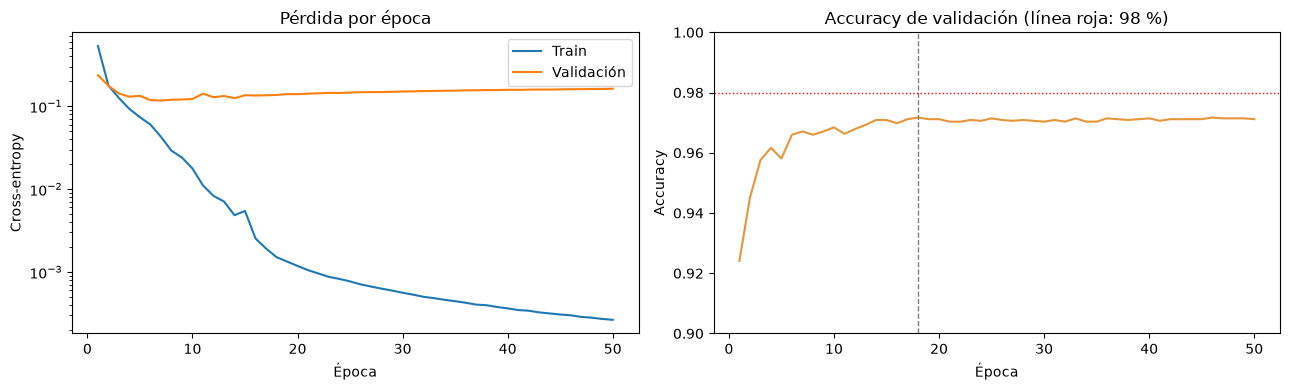

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.15, stratify=y_dev, random_state=SEED
)
print(f'Train: {len(y_train):,} | Validación: {len(y_val):,} | Test reservado: {len(y_test):,}')

model = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
history = fit(model, X_train, y_train, EPOCHS, batch_size=BATCH_SIZE, X_val=X_val, y_val=y_val, restore_best=True)
best_epoch = history.loc[history.val_accuracy.idxmax()]
print(f'Mejor época en validación: {int(best_epoch.epoch)} (accuracy {best_epoch.val_accuracy:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.epoch, history.train_loss, label='Train')
axes[0].plot(history.epoch, history.val_loss, label='Validación')
axes[0].set(title='Pérdida por época', xlabel='Época', ylabel='Cross-entropy', yscale='log')
axes[0].legend()
axes[1].plot(history.epoch, history.val_accuracy, color='#E5953A')
axes[1].axvline(best_epoch.epoch, color='gray', ls='--', lw=1)
axes[1].axhline(0.98, color='red', ls=':', lw=1)
axes[1].set(title='Accuracy de validación (línea roja: 98 %)', xlabel='Época', ylabel='Accuracy',
            ylim=(0.9, 1))
plt.tight_layout(); show('curvas_validacion_ej3')

,Experimento,Imágenes de entrenamiento,Accuracy test,F1 macro test,Recall del 5,Recall del 8
0,Ejercicio 2: solo digits.csv,12449,0.8662,0.8198,0.8565,0.0000
1,Mismo modelo + more_digits.csv,24501,0.9696,0.9690,0.9372,0.9136
2,Mismo modelo + validación (mejor época),20825,0.9656,0.9651,0.9417,0.9053


,precision,recall,f1-score,support
Dígito,,,,
0,0.9529,0.9918,0.9720,245
1,0.9824,0.9859,0.9841,283
2,0.9766,0.9690,0.9728,258
3,0.9432,0.9881,0.9651,252
4,0.9835,0.9755,0.9795,245
5,0.9722,0.9417,0.9567,223
6,0.9590,0.9791,0.9689,239
7,0.9685,0.9572,0.9628,257
8,0.9735,0.9053,0.9382,243


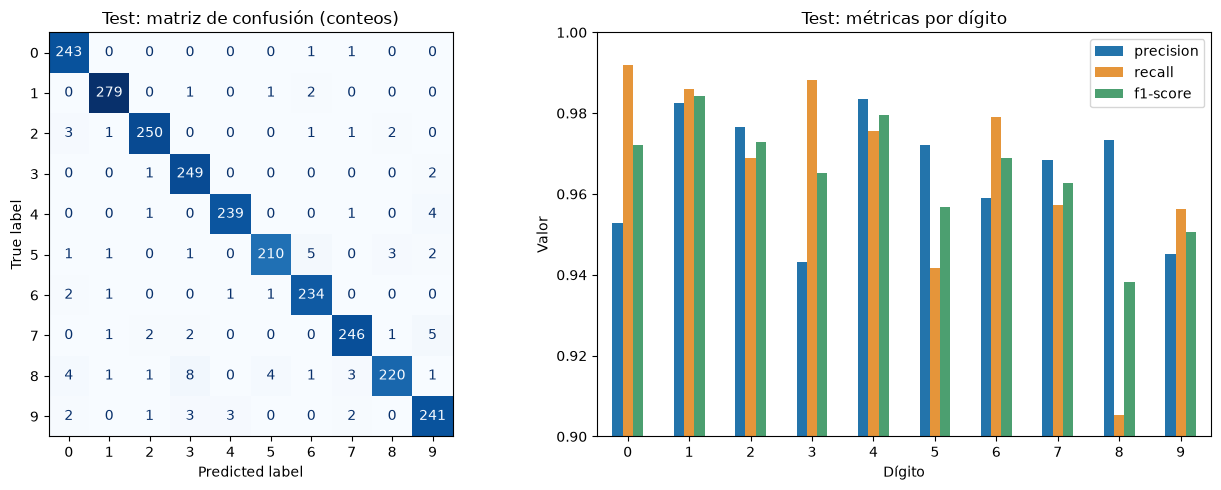

In [21]:
acc_val = accuracy_score(y_val, model.predict(X_val))
acc_test, test_report, pred_test = register('Mismo modelo + validación (mejor época)', model, len(y_train))
display(pd.DataFrame(results).style.format({'Accuracy test': '{:.4f}', 'F1 macro test': '{:.4f}',
                                            'Recall del 5': '{:.4f}', 'Recall del 8': '{:.4f}'}))
per_class = pd.DataFrame(test_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score', 'support']]
per_class.index.name = 'Dígito'
display(per_class.style.format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}', 'support': '{:.0f}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=range(10), cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Test: matriz de confusión (conteos)')
per_class[['precision', 'recall', 'f1-score']].plot.bar(ax=axes[1], rot=0, color=['#2374AB', '#E5953A', '#4C9F70'])
axes[1].set(title='Test: métricas por dígito', ylabel='Valor', ylim=(0.9, 1.0))
plt.tight_layout(); show('evaluacion_test_ej3')

## 5. Técnica 1: aumento de datos

El modelo anterior llega a 100 % en entrenamiento y se estanca en validación: memoriza las imágenes. Un perceptrón multicapa no tiene ninguna noción de posición, así que un dígito corrido dos píxeles es, para la red, una entrada distinta. El **aumento de datos** consiste en transformar cada minibatch de entrenamiento con un desplazamiento, una rotación y un zoom aleatorios y pequeños (`augment_digits` en `mlp.py`). La red nunca ve dos veces la misma imagen y la etiqueta no cambia. Validación y test se evalúan siempre con las imágenes originales.

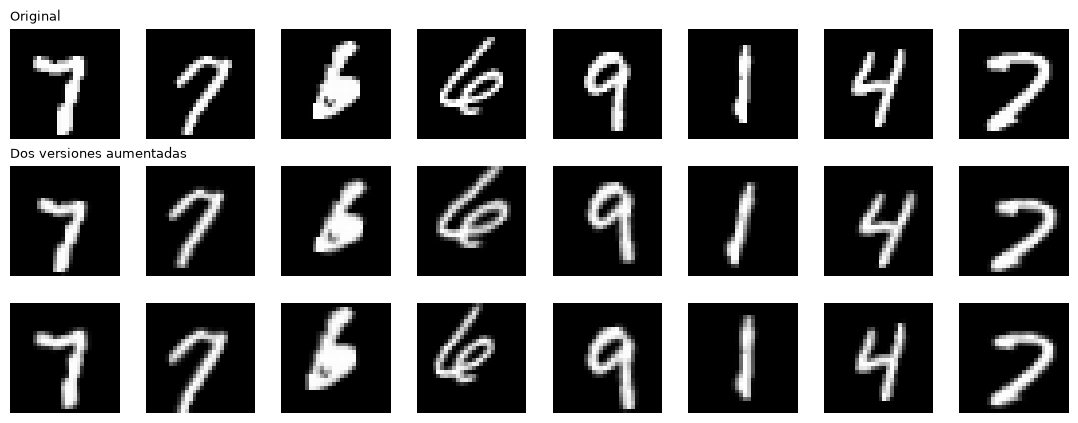

In [22]:
from functools import partial
from mlp import augment_digits

demo_gen = np.random.default_rng(SEED)
originals = X_train[:8]
fig, axes = plt.subplots(3, 8, figsize=(11, 4.3))
for row, images in enumerate([originals, augment_digits(originals, demo_gen), augment_digits(originals, demo_gen)]):
    for ax, image in zip(axes[row], images):
        ax.imshow(image.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
axes[0, 0].set_title('Original', loc='left', fontsize=9)
axes[1, 0].set_title('Dos versiones aumentadas', loc='left', fontsize=9)
plt.tight_layout(); show('ejemplos_aumento_ej3')

Comparamos en **validación** distintas intensidades de transformación, siempre con la misma red e hiperparámetros del ejercicio 2. Usamos 60 épocas porque con aumento el aprendizaje es más lento.

,Variante,Mejor accuracy validación,Accuracy validación (media últimas 5 épocas),Pérdida train final,Pérdida validación final
0,Sin aumento,0.9720,0.9717,0.0002,0.1668
1,Solo desplazamiento (±2 px),0.9834,0.9804,0.0359,0.0689
2,"Desplazamiento ±2 px, rotación ±10°, zoom ±10 %",0.9853,0.9844,0.0509,0.0555
3,"Desplazamiento ±2 px, rotación ±15°, zoom ±15 %",0.9856,0.9827,0.0738,0.0671


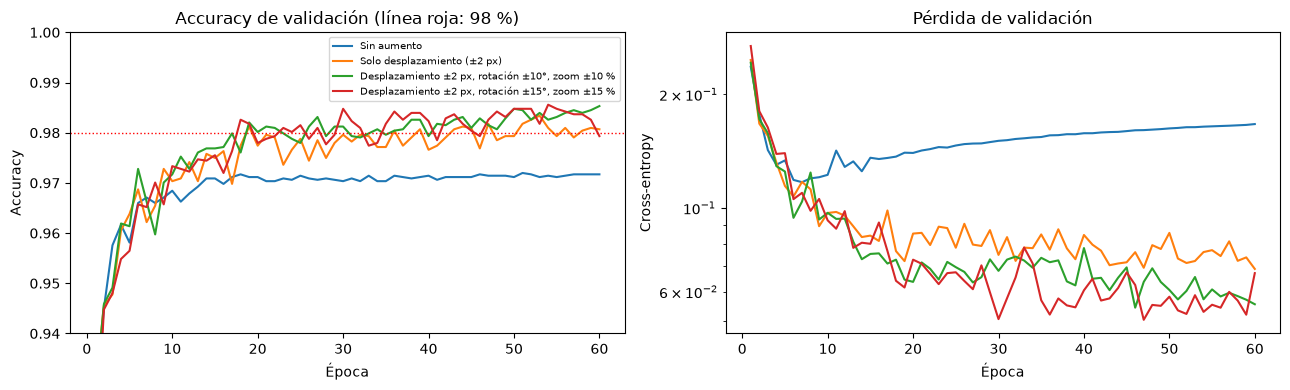

In [23]:
AUG_EPOCHS = 60
variants = {
    'Sin aumento': None,
    'Solo desplazamiento (±2 px)': dict(max_shift=2, max_rotation=0, max_zoom=0),
    'Desplazamiento ±2 px, rotación ±10°, zoom ±10 %': dict(max_shift=2, max_rotation=10, max_zoom=0.1),
    'Desplazamiento ±2 px, rotación ±15°, zoom ±15 %': dict(max_shift=2, max_rotation=15, max_zoom=0.15),
}
aug_rows, aug_histories = [], {}
for name, params in variants.items():
    candidate = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
    h = fit(candidate, X_train, y_train, AUG_EPOCHS, batch_size=BATCH_SIZE, X_val=X_val, y_val=y_val,
            augment=partial(augment_digits, **params) if params else None)
    aug_histories[name] = h
    aug_rows.append({'Variante': name, 'Mejor accuracy validación': h.val_accuracy.max(),
                     'Accuracy validación (media últimas 5 épocas)': h.val_accuracy.tail(5).mean(),
                     'Pérdida train final': h.train_loss.iloc[-1], 'Pérdida validación final': h.val_loss.iloc[-1]})
aug_results = pd.DataFrame(aug_rows)
display(aug_results.style.format({c: '{:.4f}' for c in aug_results.columns[1:]}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in aug_histories.items():
    axes[0].plot(h.epoch, h.val_accuracy, label=name)
    axes[1].plot(h.epoch, h.val_loss, label=name)
axes[0].axhline(0.98, color='red', ls=':', lw=1)
axes[0].set(title='Accuracy de validación (línea roja: 98 %)', xlabel='Época', ylabel='Accuracy', ylim=(0.94, 1))
axes[1].set(title='Pérdida de validación', xlabel='Época', ylabel='Cross-entropy', yscale='log')
axes[0].legend(fontsize=7)
plt.tight_layout(); show('comparacion_aumento_ej3')

Elegimos la variante por la media de las últimas cinco épocas de validación, que es menos sensible al ruido que el máximo de una sola época. Con esa variante entrenamos 100 épocas, nos quedamos con la mejor época en validación y recién entonces medimos en test.

Variante elegida: Desplazamiento ±2 px, rotación ±10°, zoom ±10 %
Mejor época: 96 | accuracy validación: 0.9894


,Experimento,Imágenes de entrenamiento,Accuracy test,F1 macro test,Recall del 5,Recall del 8
0,Ejercicio 2: solo digits.csv,12449,0.8662,0.8198,0.8565,0.0000
1,Mismo modelo + more_digits.csv,24501,0.9696,0.9690,0.9372,0.9136
2,Mismo modelo + validación (mejor época),20825,0.9656,0.9651,0.9417,0.9053
3,Aumento de datos (mejor época),20825,0.9812,0.9808,0.9686,0.9300


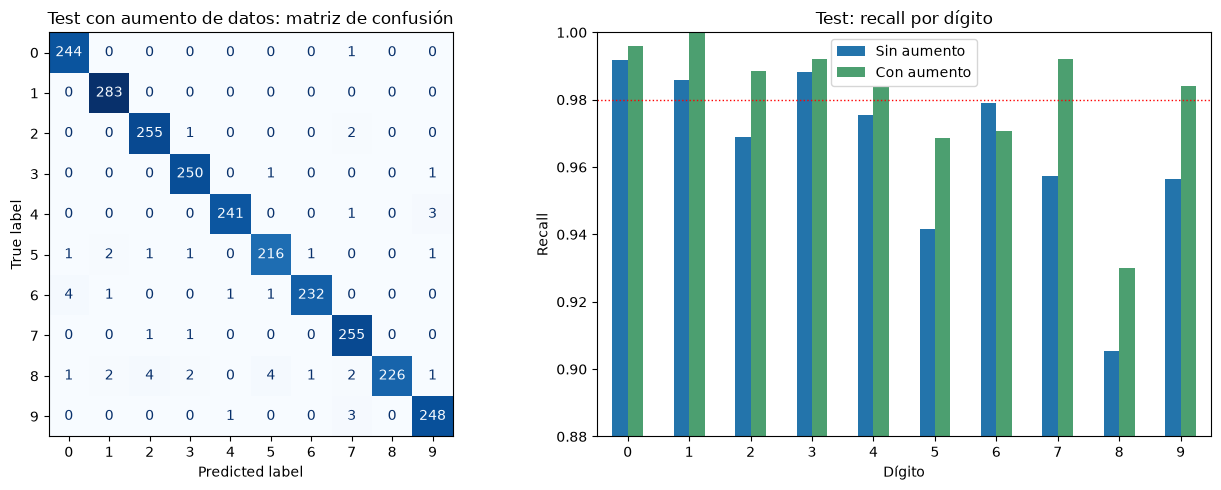

In [24]:
chosen_name = aug_results.iloc[1:].sort_values('Accuracy validación (media últimas 5 épocas)', ascending=False).iloc[0]['Variante']
AUG_PARAMS = variants[chosen_name]
FINAL_AUG_EPOCHS = 100
print('Variante elegida:', chosen_name)

aug_model = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
aug_history = fit(aug_model, X_train, y_train, FINAL_AUG_EPOCHS, batch_size=BATCH_SIZE, X_val=X_val, y_val=y_val,
                  restore_best=True, augment=partial(augment_digits, **AUG_PARAMS))
acc_aug_val = accuracy_score(y_val, aug_model.predict(X_val))
acc_aug_test, aug_report, pred_aug = register('Aumento de datos (mejor época)', aug_model, len(y_train))
print(f'Mejor época: {int(aug_history.val_accuracy.idxmax()) + 1} | accuracy validación: {acc_aug_val:.4f}')
display(pd.DataFrame(results).style.format({'Accuracy test': '{:.4f}', 'F1 macro test': '{:.4f}',
                                            'Recall del 5': '{:.4f}', 'Recall del 8': '{:.4f}'}))

aug_per_class = pd.DataFrame(aug_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score', 'support']]
aug_per_class.index.name = 'Dígito'
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_aug, labels=range(10), cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Test con aumento de datos: matriz de confusión')
pd.DataFrame({'Sin aumento': per_class['recall'], 'Con aumento': aug_per_class['recall']}).plot.bar(
    ax=axes[1], rot=0, color=['#2374AB', '#4C9F70'])
axes[1].axhline(0.98, color='red', ls=':', lw=1)
axes[1].set(title='Test: recall por dígito', ylabel='Recall', ylim=(0.88, 1.0))
plt.tight_layout(); show('evaluacion_test_aumento_ej3')

## 6. Técnica 2: ponderación de la pérdida por clase

Después del aumento de datos, los dígitos con menor recall siguen siendo el 8 y el 5, que son también los que tienen menos imágenes de entrenamiento. Como la pérdida es un promedio sobre todas las imágenes, equivocarse en una clase escasa cuesta poco y la red tiende a favorecer las clases frecuentes.

La **ponderación** multiplica el error de cada imagen por un peso según su clase: $w_c = \left(\frac{N}{10\,n_c}\right)^{\alpha}$, donde $n_c$ es la cantidad de imágenes de la clase $c$ en entrenamiento. Con $\alpha = 0$ no se pondera, con $\alpha = 1$ se compensa todo el desbalance y con $\alpha = 0{,}5$ la compensación es parcial. Los pesos se normalizan para que su promedio sobre las imágenes sea 1, así la tasa de aprendizaje conserva su escala. Se calculan solo con las etiquetas de entrenamiento y afectan solo a la pérdida de entrenamiento: validación y test se miden sin pesos.

In [25]:
from mlp import balanced_class_weights

ALPHAS = [0.0, 0.5, 1.0]
weights_table = pd.DataFrame({f'Peso (α = {alpha:g})': balanced_class_weights(y_train, alpha) for alpha in ALPHAS})
weights_table.insert(0, 'Imágenes de entrenamiento', np.bincount(y_train, minlength=10))
weights_table.index.name = 'Dígito'
display(weights_table.style.format({c: '{:.2f}' for c in weights_table.columns[1:]}))

,Imágenes de entrenamiento,Peso (α = 0),Peso (α = 0.5),Peso (α = 1)
Dígito,,,,
0,2376,1.00,0.96,0.88
1,2730,1.00,0.90,0.76
2,2394,1.00,0.96,0.87
3,2461,1.00,0.94,0.85
4,2370,1.00,0.96,0.88
5,667,1.00,1.81,3.12
6,2401,1.00,0.96,0.87
7,2524,1.00,0.93,0.83
8,497,1.00,2.10,4.19


Comparamos los tres valores de α en **validación**, siempre con el aumento de datos elegido en la sección anterior y 60 épocas. Además de la accuracy total miramos recall y precisión del 5 y del 8: la ponderación debería subir el recall de esas clases, pero puede bajar su precisión si la red empieza a predecirlas de más.

,α,Mejor accuracy validación,Accuracy validación (media últimas 5 épocas),Recall del 5,Precisión del 5,Recall del 8,Precisión del 8
0,0,0.9853,0.9844,0.9746,0.9746,0.9432,0.9326
1,0.5,0.9859,0.9824,0.9576,0.9658,0.9545,0.8571
2,1,0.9842,0.9814,0.9831,0.9134,0.9318,0.8817


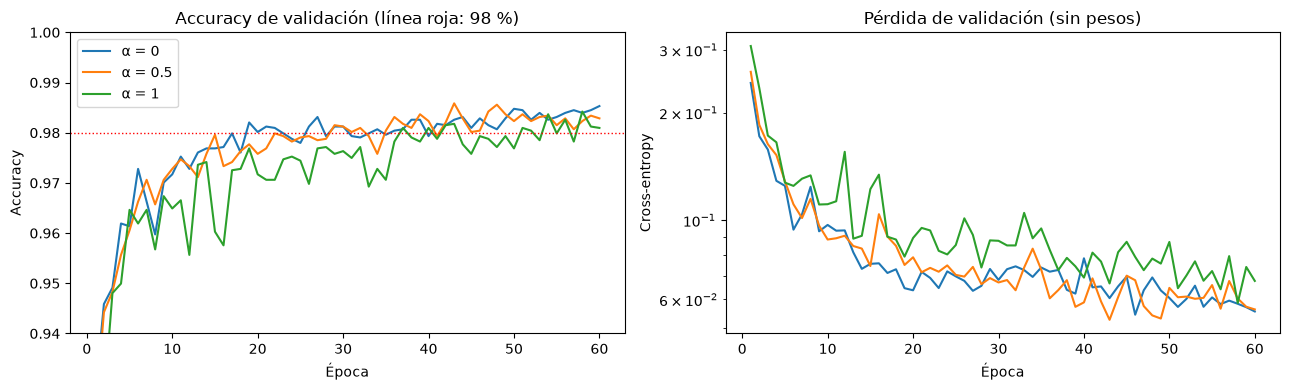

In [26]:
weight_rows, weight_histories = [], {}
for alpha in ALPHAS:
    candidate = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED,
                         class_weights=balanced_class_weights(y_train, alpha) if alpha else None)
    h = fit(candidate, X_train, y_train, AUG_EPOCHS, batch_size=BATCH_SIZE, X_val=X_val, y_val=y_val,
            augment=partial(augment_digits, **AUG_PARAMS))
    weight_histories[alpha] = h
    report = classification_report(y_val, candidate.predict(X_val), labels=range(10), output_dict=True, zero_division=0)
    weight_rows.append({'α': alpha, 'Mejor accuracy validación': h.val_accuracy.max(),
                        'Accuracy validación (media últimas 5 épocas)': h.val_accuracy.tail(5).mean(),
                        'Recall del 5': report['5']['recall'], 'Precisión del 5': report['5']['precision'],
                        'Recall del 8': report['8']['recall'], 'Precisión del 8': report['8']['precision']})
weight_results = pd.DataFrame(weight_rows)
display(weight_results.style.format({c: '{:.4f}' for c in weight_results.columns[1:]} | {'α': '{:g}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for alpha, h in weight_histories.items():
    axes[0].plot(h.epoch, h.val_accuracy, label=f'α = {alpha:g}')
    axes[1].plot(h.epoch, h.val_loss, label=f'α = {alpha:g}')
axes[0].axhline(0.98, color='red', ls=':', lw=1)
axes[0].set(title='Accuracy de validación (línea roja: 98 %)', xlabel='Época', ylabel='Accuracy', ylim=(0.94, 1))
axes[1].set(title='Pérdida de validación (sin pesos)', xlabel='Época', ylabel='Cross-entropy', yscale='log')
axes[0].legend()
plt.tight_layout(); show('comparacion_ponderacion_ej3')

Elegimos α con el mismo criterio que antes: la media de la accuracy de validación en las últimas cinco épocas. Si gana α = 0, la ponderación no aporta sobre el aumento de datos. La elección del modelo final entre todas las técnicas se hace en la sección 8.

In [27]:
VAL_METRIC = 'Accuracy validación (media últimas 5 épocas)'
best_alpha = float(weight_results.sort_values(VAL_METRIC, ascending=False, kind='stable').iloc[0]['α'])
print(f'α elegido en validación: {best_alpha:g}')
if best_alpha == 0:
    print('La ponderación no mejora la accuracy de validación respecto de usar solo aumento de datos.')

α elegido en validación: 0
La ponderación no mejora la accuracy de validación respecto de usar solo aumento de datos.


**Lectura del resultado.** La ponderación no mejora la accuracy de validación: 98,44 % sin pesos, 98,24 % con α = 0,5 y 98,14 % con α = 1. Lo que hace es mover errores de un lado a otro. En validación hay 88 imágenes del 8 y 118 del 5:

- Con α = 0,5 el 8 gana un acierto (de 83 a 84), pero las predicciones erróneas de «8» pasan de 6 a 14 (la precisión baja de 0,93 a 0,86), y el 5 pierde dos aciertos.
- Con α = 1 el 5 gana un acierto (de 115 a 116) a cambio de pasar de 3 a 11 predicciones erróneas de «5», y el 8 pierde un acierto.

La interpretación es que, con el aumento de datos ya aplicado, lo que limita al 8 y al 5 no es que pesen poco en la pérdida sino que hay pocos ejemplos distintos de esos dígitos (497 y 667 en entrenamiento). Darles más peso desplaza la frontera de decisión hacia esas clases sin aportar información nueva.

Estas diferencias son de pocas imágenes y con una sola semilla. Además, el resultado de una misma configuración puede variar alrededor de una décima entre ejecuciones del notebook (se observó en α = 1), así que estos números no alcanzan para afirmar que la ponderación perjudica; sí alcanzan para no adoptarla. Queda documentada como experimento.

## 7. Técnica 3: sobremuestreo del 5 y del 8

La ponderación mostró que darle más importancia al 5 y al 8 en la pérdida no alcanza. El **sobremuestreo** ataca el mismo desbalance de otra forma: repite imágenes de las clases escasas hasta acercarlas en cantidad a las demás. Solo, tendría el riesgo de que la red memorice esas pocas imágenes repetidas; combinado con el aumento de datos, cada copia recibe un desplazamiento, una rotación y un zoom distintos, así que la red ve muchas más variantes de cada 5 y de cada 8 por época.

Se conservan todas las imágenes originales y se agregan copias elegidas al azar con reposición. El nivel indica hasta qué fracción de la clase más numerosa se completan las clases escasas. Se aplica **solo al conjunto de entrenamiento**; validación y test no cambian.

In [28]:
def oversample_indices(y, fraction, gen):
    """Índices de y con las clases escasas completadas hasta fraction × (tamaño de la clase mayor)."""
    counts = np.bincount(y, minlength=10)
    target = int(round(fraction * counts.max()))
    parts = []
    for digit in range(10):
        members = np.flatnonzero(y == digit)
        parts.append(members)
        if 0 < len(members) < target:
            parts.append(gen.choice(members, target - len(members), replace=True))
    return np.concatenate(parts)


LEVELS = {'Parcial (50 % de la clase mayor)': 0.5, 'Completo (100 % de la clase mayor)': 1.0}
oversampled = {name: oversample_indices(y_train, fraction, np.random.default_rng(SEED))
               for name, fraction in LEVELS.items()}
level_counts = pd.DataFrame({'Sin sobremuestreo': np.bincount(y_train, minlength=10)}
                            | {name: np.bincount(y_train[idx], minlength=10) for name, idx in oversampled.items()})
level_counts.index.name = 'Dígito'
level_counts.loc['Total'] = level_counts.sum()
display(level_counts)

,Sin sobremuestreo,Parcial (50 % de la clase mayor),Completo (100 % de la clase mayor)
Dígito,,,
0,2376,2376,2730
1,2730,2730,2730
2,2394,2394,2730
3,2461,2461,2730
4,2370,2370,2730
5,667,1365,2730
6,2401,2401,2730
7,2524,2524,2730
8,497,1365,2730


Comparamos los niveles en **validación** con la misma red, el aumento de datos elegido y 60 épocas. El caso sin sobremuestreo es exactamente la configuración α = 0 de la sección anterior, así que reutilizamos ese resultado en lugar de entrenarlo otra vez.

,Nivel,Mejor accuracy validación,Accuracy validación (media últimas 5 épocas),Recall del 5,Precisión del 5,Recall del 8,Precisión del 8
0,Sin sobremuestreo,0.9853,0.9844,0.9746,0.9746,0.9432,0.9326
1,Parcial (50 % de la clase mayor),0.9850,0.9829,0.9915,0.9000,0.9091,0.9524
2,Completo (100 % de la clase mayor),0.9861,0.9833,0.9915,0.9360,0.9318,0.9425


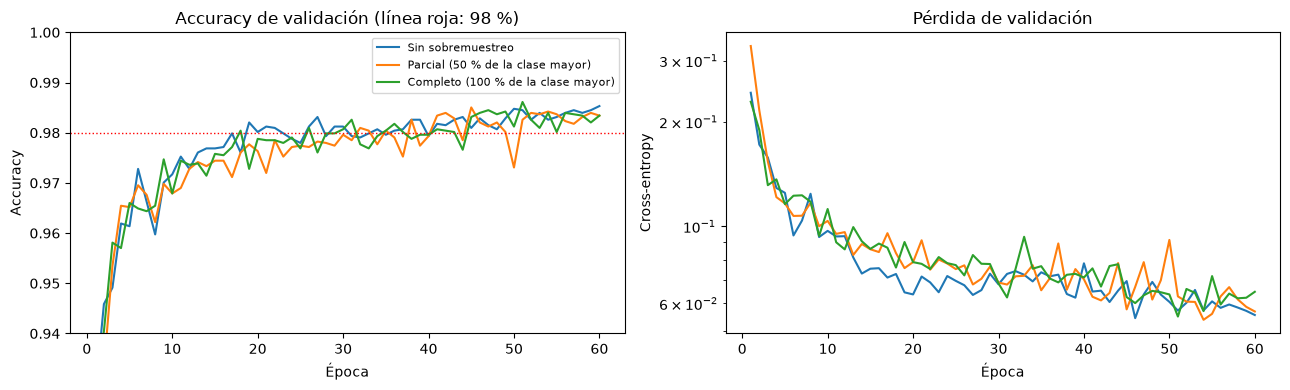

In [29]:
reference = weight_results[weight_results['α'] == 0].iloc[0]
over_rows = [{'Nivel': 'Sin sobremuestreo', **reference.drop('α').to_dict()}]
over_histories = {'Sin sobremuestreo': weight_histories[0.0]}
for name, idx in oversampled.items():
    candidate = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED)
    h = fit(candidate, X_train[idx], y_train[idx], AUG_EPOCHS, batch_size=BATCH_SIZE, X_val=X_val, y_val=y_val,
            augment=partial(augment_digits, **AUG_PARAMS))
    over_histories[name] = h
    report = classification_report(y_val, candidate.predict(X_val), labels=range(10), output_dict=True, zero_division=0)
    over_rows.append({'Nivel': name, 'Mejor accuracy validación': h.val_accuracy.max(),
                      VAL_METRIC: h.val_accuracy.tail(5).mean(),
                      'Recall del 5': report['5']['recall'], 'Precisión del 5': report['5']['precision'],
                      'Recall del 8': report['8']['recall'], 'Precisión del 8': report['8']['precision']})
over_results = pd.DataFrame(over_rows)
display(over_results.style.format({col: '{:.4f}' for col in over_results.columns[1:]}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in over_histories.items():
    axes[0].plot(h.epoch, h.val_accuracy, label=name)
    axes[1].plot(h.epoch, h.val_loss, label=name)
axes[0].axhline(0.98, color='red', ls=':', lw=1)
axes[0].set(title='Accuracy de validación (línea roja: 98 %)', xlabel='Época', ylabel='Accuracy', ylim=(0.94, 1))
axes[1].set(title='Pérdida de validación', xlabel='Época', ylabel='Cross-entropy', yscale='log')
axes[0].legend(fontsize=8)
plt.tight_layout(); show('comparacion_sobremuestreo_ej3')

In [30]:
best_level = over_results.sort_values(VAL_METRIC, ascending=False, kind='stable').iloc[0]['Nivel']
print('Nivel elegido en validación:', best_level)
if best_level == 'Sin sobremuestreo':
    print('El sobremuestreo no mejora la accuracy de validación respecto de usar solo aumento de datos.')

Nivel elegido en validación: Sin sobremuestreo
El sobremuestreo no mejora la accuracy de validación respecto de usar solo aumento de datos.


**Lectura del resultado.** El sobremuestreo tampoco mejora la accuracy de validación: 98,44 % sin sobremuestreo, 98,29 % con el nivel parcial y 98,33 % con el completo. El efecto por clase es distinto al de la ponderación, pero el balance vuelve a ser neutro o levemente negativo:

- El 5 mejora en recall en ambos niveles (de 115 a 117 aciertos sobre 118), pero la red predice «5» de más: las predicciones erróneas pasan de 3 a 13 con el nivel parcial y a 8 con el completo.
- El 8 no mejora: el recall baja de 83 a 80 y 82 aciertos sobre 88, aunque su precisión sube un poco.

Con el aumento de datos activo, cada copia sobremuestreada se ve distinta, así que no hay señales de que la red memorice esas imágenes; simplemente no hay ganancia. Junto con el resultado de la ponderación, esto indica que el desbalance en sí ya no es el problema: lo que falta son más formas distintas de escribir un 5 y un 8, y ninguna de las dos técnicas las aporta.

Las diferencias entre niveles son de 4 a 6 imágenes sobre 3.676, del mismo orden que el ruido entre ejecuciones, por lo que el sobremuestreo no se adopta y queda documentado como experimento. Ambas técnicas se evaluaron siempre sobre el modelo con aumento de datos; no se midió su efecto sin aumento.

## 8. Modelo final

Los candidatos son el aumento de datos solo, el aumento con la mejor ponderación y el aumento con el mejor nivel de sobremuestreo. No combinamos ponderación y sobremuestreo porque corrigen el mismo desbalance dos veces. Elegimos el candidato con mayor accuracy de validación (media de las últimas cinco épocas); en caso de empate queda el más simple. Si gana una técnica de balanceo, la entrenamos 100 épocas, nos quedamos con la mejor época en validación y la medimos en test. **El test no interviene en la elección.**

,Candidato,Accuracy validación (media últimas 5 épocas)
0,Aumento de datos,0.9844


Modelo final: Aumento de datos


,Experimento,Imágenes de entrenamiento,Accuracy test,F1 macro test,Recall del 5,Recall del 8
0,Ejercicio 2: solo digits.csv,12449,0.8662,0.8198,0.8565,0.0000
1,Mismo modelo + more_digits.csv,24501,0.9696,0.9690,0.9372,0.9136
2,Mismo modelo + validación (mejor época),20825,0.9656,0.9651,0.9417,0.9053
3,Aumento de datos (mejor época),20825,0.9812,0.9808,0.9686,0.9300


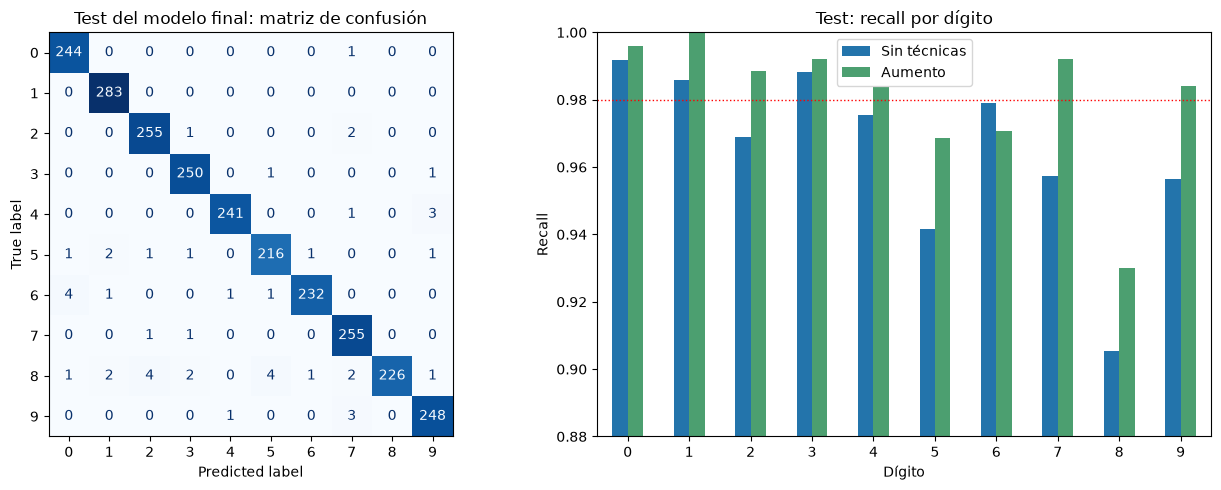

In [31]:
candidates = [{'Candidato': 'Aumento de datos', 'tipo': 'aumento',
               VAL_METRIC: weight_results.loc[weight_results['α'] == 0, VAL_METRIC].iloc[0]}]
if best_alpha > 0:
    candidates.append({'Candidato': f'Aumento + ponderación α = {best_alpha:g}', 'tipo': 'ponderacion',
                       VAL_METRIC: weight_results.loc[weight_results['α'] == best_alpha, VAL_METRIC].iloc[0]})
if best_level != 'Sin sobremuestreo':
    candidates.append({'Candidato': f'Aumento + sobremuestreo: {best_level}', 'tipo': 'sobremuestreo',
                       VAL_METRIC: over_results.loc[over_results['Nivel'] == best_level, VAL_METRIC].iloc[0]})
candidates = pd.DataFrame(candidates)
display(candidates.drop(columns='tipo').style.format({VAL_METRIC: '{:.4f}'}))
winner = candidates.sort_values(VAL_METRIC, ascending=False, kind='stable').iloc[0]
final_name = winner['Candidato']
print('Modelo final:', final_name)

if winner['tipo'] == 'aumento':
    final_model, final_acc_val, final_acc_test = aug_model, acc_aug_val, acc_aug_test
    final_report, final_pred = aug_report, pred_aug
else:
    idx = oversampled[best_level] if winner['tipo'] == 'sobremuestreo' else np.arange(len(y_train))
    final_model = DigitMLP(HIDDEN, lr=LR, optimizer=OPTIMIZER, seed=SEED,
                           class_weights=balanced_class_weights(y_train, best_alpha) if winner['tipo'] == 'ponderacion' else None)
    final_history = fit(final_model, X_train[idx], y_train[idx], FINAL_AUG_EPOCHS, batch_size=BATCH_SIZE,
                        X_val=X_val, y_val=y_val, restore_best=True, augment=partial(augment_digits, **AUG_PARAMS))
    final_acc_val = accuracy_score(y_val, final_model.predict(X_val))
    final_acc_test, final_report, final_pred = register(f'{final_name} (mejor época)', final_model, len(idx))
    print(f'Mejor época: {int(final_history.val_accuracy.idxmax()) + 1} | accuracy validación: {final_acc_val:.4f}')

display(pd.DataFrame(results).style.format({'Accuracy test': '{:.4f}', 'F1 macro test': '{:.4f}',
                                            'Recall del 5': '{:.4f}', 'Recall del 8': '{:.4f}'}))
final_per_class = pd.DataFrame(final_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score', 'support']]
final_per_class.index.name = 'Dígito'
recalls = {'Sin técnicas': per_class['recall'], 'Aumento': aug_per_class['recall']}
if winner['tipo'] != 'aumento':
    recalls['Modelo final'] = final_per_class['recall']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, labels=range(10), cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Test del modelo final: matriz de confusión')
pd.DataFrame(recalls).plot.bar(ax=axes[1], rot=0, color=['#2374AB', '#4C9F70', '#E5953A'][:len(recalls)])
axes[1].axhline(0.98, color='red', ls=':', lw=1)
axes[1].set(title='Test: recall por dígito', ylabel='Recall', ylim=(0.88, 1.0))
plt.tight_layout(); show('evaluacion_test_final_ej3')

In [32]:
es = lambda text: text.replace('.', ',')
errors = int((final_pred != y_test).sum())
allowed = len(y_test) - int(np.ceil(0.98 * len(y_test)))
worst = final_per_class.sort_values('recall').head(3)
weight_summary = ', '.join(f'α = {es(format(row["α"], "g"))}: {es(format(row[VAL_METRIC], ".2%"))}'
                           for _, row in weight_results.iterrows())
over_summary = ', '.join(f'{row["Nivel"].lower()}: {es(format(row[VAL_METRIC], ".2%"))}' for _, row in over_results.iterrows())
verdict = lambda kind, improves: ('Es la técnica del modelo final.' if winner['tipo'] == kind else
                                  'Mejora en validación pero no supera al candidato elegido.' if improves else
                                  'No mejoró la accuracy de validación y se descartó.')
display(Markdown(
    f'## 9. Estado actual\n\n'
    f'**Objetivo del 98 %: {"alcanzado" if final_acc_test >= 0.98 else "todavía no alcanzado"}.** El modelo final llega a '
    f'**{es(f"{final_acc_test:.2%}")}** en test ({errors} errores sobre {len(y_test)}; para 98 % puede haber como máximo '
    f'{allowed}). En validación obtiene {es(f"{final_acc_val:.2%}")}.\n\n'
    f'**(a) Mejor resultado.** Accuracy de test {es(f"{final_acc_test:.2%}")} con el modelo «{final_name}»: capas ocultas '
    f'{HIDDEN}, {OPTIMIZER}, tasa {es(f"{LR:g}")}, minibatches de {BATCH_SIZE} y aumento de datos «{chosen_name}». '
    f'El modelo final es el elegido en validación, no el de mayor accuracy en test.\n\n'
    f'**(b) Técnicas de mejora.**\n\n'
    f'- *Aumento de datos:* en test pasa de {es(f"{acc_test:.2%}")} a {es(f"{acc_aug_test:.2%}")} con la misma red, '
    f'los mismos hiperparámetros y la misma partición.\n'
    f'- *Ponderación de la pérdida por clase:* accuracy de validación (media de las últimas 5 épocas) {weight_summary}. '
    f'{verdict("ponderacion", best_alpha > 0)}\n'
    f'- *Sobremuestreo del 5 y del 8:* accuracy de validación (media de las últimas 5 épocas) {over_summary}. '
    f'{verdict("sobremuestreo", best_level != "Sin sobremuestreo")}\n\n'
    f'Los dígitos con menor recall en test son {", ".join(worst.index)}. Quedan sin probar la regularización, '
    f'redes más anchas y el ensamble.\n\n'
    f'**(c) Factores ajenos a las técnicas.** Con el mismo modelo e hiperparámetros, pasar de `digits.csv` al conjunto '
    f'combinado lleva la accuracy de test de {es(f"{acc_baseline:.2%}")} a {es(f"{acc_data:.2%}")}. Esa mejora se debe '
    f'solo a los datos: `digits.csv` no tenía ningún 8 y tenía pocos 5.\n\n'
    f'**Límites.** Cada configuración se entrenó con una sola semilla y una sola partición; diferencias de pocas décimas '
    f'entre variantes pueden ser ruido.'
))

## 9. Estado actual

**Objetivo del 98 %: alcanzado.** El modelo final llega a **98,12%** en test (47 errores sobre 2497; para 98 % puede haber como máximo 49). En validación obtiene 98,94%.

**(a) Mejor resultado.** Accuracy de test 98,12% con el modelo «Aumento de datos»: capas ocultas (128, 64), momentum, tasa 0,1, minibatches de 256 y aumento de datos «Desplazamiento ±2 px, rotación ±10°, zoom ±10 %». El modelo final es el elegido en validación, no el de mayor accuracy en test.

**(b) Técnicas de mejora.**

- *Aumento de datos:* en test pasa de 96,56% a 98,12% con la misma red, los mismos hiperparámetros y la misma partición.
- *Ponderación de la pérdida por clase:* accuracy de validación (media de las últimas 5 épocas) α = 0: 98,44%, α = 0,5: 98,24%, α = 1: 98,14%. No mejoró la accuracy de validación y se descartó.
- *Sobremuestreo del 5 y del 8:* accuracy de validación (media de las últimas 5 épocas) sin sobremuestreo: 98,44%, parcial (50 % de la clase mayor): 98,29%, completo (100 % de la clase mayor): 98,33%. No mejoró la accuracy de validación y se descartó.

Los dígitos con menor recall en test son 8, 5, 6. Quedan sin probar la regularización, redes más anchas y el ensamble.

**(c) Factores ajenos a las técnicas.** Con el mismo modelo e hiperparámetros, pasar de `digits.csv` al conjunto combinado lleva la accuracy de test de 86,62% a 96,96%. Esa mejora se debe solo a los datos: `digits.csv` no tenía ningún 8 y tenía pocos 5.

**Límites.** Cada configuración se entrenó con una sola semilla y una sola partición; diferencias de pocas décimas entre variantes pueden ser ruido.